In [1]:
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 37.6 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 36.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nilearn.image as niimg
import nilearn.plotting as niplt
import os
from nilearn.image import resample_to_img
from nilearn import datasets
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

In [49]:
path = '/srv/tempdd/egermani/hcp_pipelines/data/derived/fsl_preprocessing/registration_fsl/'
participants = ["118528",'131823','135124','176542']
# "131823","135124","118528"
fwhm_values = [5, 8]
hrf_derivatives = {"no": "no_derivatives","yes": "derivatives"}
nb_param_values = [0, 6, 24]
task = 'MOTOR'
contrasts = [1,2,3,4,5]

filename_template = (
    path +
    "_contrast_{contrast}_fwhm_{fwhm}_hrf_{hrf_full}_nb_param_{nb_param}_subject_id_{subject}_task_{task}" +
    "/_warpall_stat0/tstat{contrast}_warp.nii.gz"
)

loaded = {}

data_arrays = {}

for subj in participants:
    subj_key = f"s{subj}"
    loaded[subj_key] = {}
    data_arrays[subj_key] = {}
    
    for fwhm in fwhm_values:
        for hrf_short, hrf_full in hrf_derivatives.items():
            for nb_param in nb_param_values:

                pipeline_name = f"{subj_key}_fwhm{fwhm}_hrf{hrf_short}_param{nb_param}"
                loaded[subj_key][pipeline_name] = {}
                data_arrays[subj_key][pipeline_name] = {}

                for contrast in contrasts:

                    filename = filename_template.format(
                        subject=subj,
                        fwhm=fwhm,
                        hrf_full=hrf_full,
                        nb_param=nb_param,
                        task=task,
                        contrast=contrast
                    )

                    if not os.path.exists(filename):
                        print(f"Missing: {filename}")
                        continue
                        
                    img = niimg.load_img(filename)

                    loaded[subj_key][pipeline_name][contrast] = img
                    data_arrays[subj_key][pipeline_name][contrast] = img.get_fdata()

                    print(f"Loaded: {pipeline_name}_contrast{contrast}")


Loaded: s118528_fwhm5_hrfno_param0_contrast1
Loaded: s118528_fwhm5_hrfno_param0_contrast2
Loaded: s118528_fwhm5_hrfno_param0_contrast3
Loaded: s118528_fwhm5_hrfno_param0_contrast4
Loaded: s118528_fwhm5_hrfno_param0_contrast5
Loaded: s118528_fwhm5_hrfno_param6_contrast1
Loaded: s118528_fwhm5_hrfno_param6_contrast2
Loaded: s118528_fwhm5_hrfno_param6_contrast3
Loaded: s118528_fwhm5_hrfno_param6_contrast4
Loaded: s118528_fwhm5_hrfno_param6_contrast5
Loaded: s118528_fwhm5_hrfno_param24_contrast1
Loaded: s118528_fwhm5_hrfno_param24_contrast2
Loaded: s118528_fwhm5_hrfno_param24_contrast3
Loaded: s118528_fwhm5_hrfno_param24_contrast4
Loaded: s118528_fwhm5_hrfno_param24_contrast5
Loaded: s118528_fwhm5_hrfyes_param0_contrast1
Loaded: s118528_fwhm5_hrfyes_param0_contrast2
Loaded: s118528_fwhm5_hrfyes_param0_contrast3
Loaded: s118528_fwhm5_hrfyes_param0_contrast4
Loaded: s118528_fwhm5_hrfyes_param0_contrast5
Loaded: s118528_fwhm5_hrfyes_param6_contrast1
Loaded: s118528_fwhm5_hrfyes_param6_contrast

Loaded: s176542_fwhm5_hrfno_param6_contrast4
Loaded: s176542_fwhm5_hrfno_param6_contrast5
Loaded: s176542_fwhm5_hrfno_param24_contrast1
Loaded: s176542_fwhm5_hrfno_param24_contrast2
Loaded: s176542_fwhm5_hrfno_param24_contrast3
Loaded: s176542_fwhm5_hrfno_param24_contrast4
Loaded: s176542_fwhm5_hrfno_param24_contrast5
Loaded: s176542_fwhm5_hrfyes_param0_contrast1
Loaded: s176542_fwhm5_hrfyes_param0_contrast2
Loaded: s176542_fwhm5_hrfyes_param0_contrast3
Loaded: s176542_fwhm5_hrfyes_param0_contrast4
Loaded: s176542_fwhm5_hrfyes_param0_contrast5
Loaded: s176542_fwhm5_hrfyes_param6_contrast1
Loaded: s176542_fwhm5_hrfyes_param6_contrast2
Loaded: s176542_fwhm5_hrfyes_param6_contrast3
Loaded: s176542_fwhm5_hrfyes_param6_contrast4
Loaded: s176542_fwhm5_hrfyes_param6_contrast5
Loaded: s176542_fwhm5_hrfyes_param24_contrast1
Loaded: s176542_fwhm5_hrfyes_param24_contrast2
Loaded: s176542_fwhm5_hrfyes_param24_contrast3
Loaded: s176542_fwhm5_hrfyes_param24_contrast4
Loaded: s176542_fwhm5_hrfyes_par

In [50]:
arr = data_arrays["s118528"]["s118528_fwhm5_hrfno_param6"][1]
arr.shape

(91, 109, 91)

In [1]:
# load atlas
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()
atlas_img.shape

NameError: name 'datasets' is not defined

In [52]:
roi_labels = atlas.labels[1:] #excludes background
roi_indices = range(1, len(roi_labels) + 1)
roi_labels_dict = {idx: label for idx, label in zip(roi_indices, roi_labels)}
roi_labels_dict

{1: 'Frontal Pole',
 2: 'Insular Cortex',
 3: 'Superior Frontal Gyrus',
 4: 'Middle Frontal Gyrus',
 5: 'Inferior Frontal Gyrus, pars triangularis',
 6: 'Inferior Frontal Gyrus, pars opercularis',
 7: 'Precentral Gyrus',
 8: 'Temporal Pole',
 9: 'Superior Temporal Gyrus, anterior division',
 10: 'Superior Temporal Gyrus, posterior division',
 11: 'Middle Temporal Gyrus, anterior division',
 12: 'Middle Temporal Gyrus, posterior division',
 13: 'Middle Temporal Gyrus, temporooccipital part',
 14: 'Inferior Temporal Gyrus, anterior division',
 15: 'Inferior Temporal Gyrus, posterior division',
 16: 'Inferior Temporal Gyrus, temporooccipital part',
 17: 'Postcentral Gyrus',
 18: 'Superior Parietal Lobule',
 19: 'Supramarginal Gyrus, anterior division',
 20: 'Supramarginal Gyrus, posterior division',
 21: 'Angular Gyrus',
 22: 'Lateral Occipital Cortex, superior division',
 23: 'Lateral Occipital Cortex, inferior division',
 24: 'Intracalcarine Cortex',
 25: 'Frontal Medial Cortex',
 26: '

In [53]:
def parse_pipeline_name(pipeline_name):
    # example: "s116727_fwhm5_hrfno_param6"
    parts = pipeline_name.split("_")
    fwhm = int(parts[1].replace("fwhm",""))
    hrf = 0 if "hrfno" in parts[2] else 1
    motion_reg = int(parts[3].replace("param",""))
    return fwhm, hrf, motion_reg

In [54]:
# create masks for each ROI
atlas_arr = atlas_img.get_fdata().astype(int)

roi_masks = {}
for roi_idx in roi_indices:
    roi_masks[roi_idx] = (atlas_arr == roi_idx)  

In [55]:
roi_contrast_dfs = {
    (roi_idx, contrast): []
    for roi_idx in roi_indices
    for contrast in contrasts
}

In [56]:
# create dfs for each ROI and each contrast
for subj in participants:
    subj_key = f"s{subj}"

    for pipeline in data_arrays[subj_key]:
        fwhm, hrf, motion_reg = parse_pipeline_name(pipeline)

        for contrast in data_arrays[subj_key][pipeline]:

            vol = data_arrays[subj_key][pipeline][contrast]

            for roi_idx in roi_indices:

                mask = roi_masks[roi_idx]     
                roi_values = vol[mask]       

                roi_contrast_dfs[(roi_idx, contrast)].append(pd.DataFrame({
                    "subj_id": subj,
                    "tvalue": roi_values,
                    "fwhm": fwhm,
                    "motion_reg": motion_reg,
                    "hrf": hrf,
                    "contrast": contrast,
                    "roi": roi_idx
                }))

In [57]:
roi_contrast_dfs = {
    f"roi_{roi_idx}_contrast_{contrast}": pd.concat(df_list, ignore_index=True)
    for (roi_idx, contrast), df_list in roi_contrast_dfs.items()
}

In [58]:
roi_contrast_dfs['roi_1_contrast_1'].head()

,subj_id,tvalue,fwhm,motion_reg,hrf,contrast,roi
0,118528,-5.039628,5,0,0,1,1
1,118528,-4.857032,5,0,0,1,1
2,118528,-3.601366,5,0,0,1,1
3,118528,-2.842743,5,0,0,1,1
4,118528,-4.011854,5,0,0,1,1


In [59]:
unique_labels, counts = np.unique(atlas_arr, return_counts=True)
counts # the first number is background, ROI 1 has 15397 voxels

array([771555,  15397,   2341,   5080,   5316,   1103,   1384,   8573,
         4711,    521,   1830,    848,   2525,   2004,    647,   1942,
         1470,   6895,   2908,   1742,   2259,   2409,   9779,   4089,
         1401,    976,   1484,   1142,   2944,   2592,   2412,   5623,
         1227,   3148,   1248,    710,   3381,    610,   1594,   1469,
         1806,    687,   1886,   1119,    749,    604,    952,    261,
         5276])

In [60]:
roi_contrast_dfs['roi_1_contrast_1'].shape

(739056, 7)

In [61]:
#check shape:
554292/15397 #36 = 3 (subjects) * 12 (pipelines)

36.0

In [38]:
# Test statistical analysis for 1 ROI 1 contrast

# this was the original code, where fdr corrected p-values were NAs, which seemed to be caused by the NAs in 
# Group Var. I wasn't sure if it makes sense to drop the NAs there? but the next block is with dropped NAs before 
# computing fdr correction

df = roi_contrast_dfs["roi_1_contrast_1"].copy()

df["subj_id"] = df["subj_id"].astype(str)
                                   
model = smf.mixedlm(
    "tvalue ~ fwhm + motion_reg + hrf",
    data=df,
    groups=df["subj_id"],
    re_formula="1"
)
result = model.fit()

results_table = pd.DataFrame({
    "coef": result.fe_params,
    "t_value": result.tvalues,
    "p_value": result.pvalues
})

# Apply FDR correction (BH procedure)
pvals = results_table["p_value"].values
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

results_table["p_fdr"] = pvals_fdr
results_table["reject_fdr"] = reject

print(results_table)

                coef    t_value       p_value  p_fdr  reject_fdr
Group Var        NaN        NaN           NaN    NaN       False
Intercept   0.177464   0.130563  8.961208e-01    NaN       False
fwhm       -0.114297 -54.221352  0.000000e+00    NaN        True
hrf         0.007369   1.165207  2.439351e-01    NaN       False
motion_reg -0.001841  -5.936909  2.904462e-09    NaN        True


/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [70]:
# Test statistical analysis for 1 ROI 1 contrast

# this was the original code, where fdr corrected p-values were NAs, which seemed to be caused by the NAs in 
# Group Var. I wasn't sure if it makes sense to drop the NAs there? but the next block is with dropped NAs before 
# computing fdr correction

df = roi_contrast_dfs["roi_1_contrast_1"].copy()

df["subj_id"] = df["subj_id"].astype(str)


model = smf.glm(
    "tvalue ~ fwhm + motion_reg + hrf",
    data=df,
)
result = model.fit()

# results_table = pd.DataFrame({
# #     "coef": result.fe_params,
#     "t_value": result.tvalues,
#     "p_value": result.pvalues
# })

# print(results_table)

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 tvalue   No. Observations:               554292
Model:                            GLM   Df Residuals:                   554288
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          6.2496
Method:                          IRLS   Log-Likelihood:            -1.2944e+06
Date:                Fri, 05 Dec 2025   Deviance:                   3.4641e+06
Time:                        17:41:38   Pearson chi2:                 3.46e+06
No. Iterations:                     3   Pseudo R-squ. (CS):           0.004750
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1775      0.016     11.335      0.0

In [71]:
results_table

,coef,t_value,p_value,p_fdr,reject_fdr
Group Var,NaN,NaN,NaN,NaN,False
Intercept,0.177464,0.130563,8.961208e-01,NaN,False
fwhm,-0.114297,-54.221352,0.000000e+00,NaN,True
hrf,0.007369,1.165207,2.439351e-01,NaN,False
motion_reg,-0.001841,-5.936909,2.904462e-09,NaN,True


<AxesSubplot:xlabel='tvalue', ylabel='Count'>

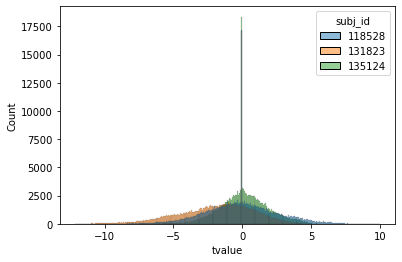

In [63]:
# len(np.unique(model.endog_li[0]))
# df.shape[]
# len(np.unique(model.endog_li[0]))/(15397*12)
import seaborn as sns
sns.histplot(data = df, x = "tvalue", hue="subj_id")

In [62]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

final_rows = []
failed = []

# iterate roi x contrast
for roi_idx in range(1, 49):            # 1..48 (some may be missing in atlas image)
    for contrast_idx in range(1, 6):   # 1..5

        key = f"roi_{roi_idx}_contrast_{contrast_idx}"

        # skip keys that do not exist or are empty
        if key not in roi_contrast_dfs:
            failed.append((key, "missing_key"))
            continue

        df = roi_contrast_dfs[key]
        if df is None or df.shape[0] == 0:
            failed.append((key, "empty_df"))
            continue

        # require at least 2 subjects for random intercepts
        try:
            df2 = df.copy()
            df2["subj_id"] = df2["subj_id"].astype(str)
        except Exception as e:
            failed.append((key, f"bad_subj_id_cast: {e}"))
            continue

        if df2["subj_id"].nunique() < 2:
            failed.append((key, "not_enough_subjects"))
            continue

        # Fit model
        try:
            model = smf.mixedlm(
                "tvalue ~ fwhm + motion_reg + hrf",
                data=df2,
                groups=df2["subj_id"],
                re_formula="1"
            )
            result = model.fit()
        except Exception as e:
            failed.append((key, f"fit_error: {e}"))
            continue

        # Extract fixed-effect estimates safely (use .get to avoid KeyError)
        # stats may be missing for some terms → use np.nan
        def safe_get(series, name):
            try:
                return series.get(name, np.nan)
            except Exception:
                return np.nan

        fwhm_coef = safe_get(result.fe_params, "fwhm")
        hrf_coef = safe_get(result.fe_params, "hrf")
        motion_coef = safe_get(result.fe_params, "motion_reg")

        fwhm_t = safe_get(result.tvalues, "fwhm")
        hrf_t = safe_get(result.tvalues, "hrf")
        motion_t = safe_get(result.tvalues, "motion_reg")

        fwhm_p = safe_get(result.pvalues, "fwhm")
        hrf_p = safe_get(result.pvalues, "hrf")
        motion_p = safe_get(result.pvalues, "motion_reg")

        final_rows.append({
            "roi": roi_idx,
            "contrast": contrast_idx,

            "fwhm_coef": fwhm_coef,
            "hrf_coef": hrf_coef,
            "motion_reg_coef": motion_coef,

            "fwhm_t_value": fwhm_t,
            "hrf_t_value": hrf_t,
            "motion_reg_t_value": motion_t,

            "fwhm_p_value": fwhm_p,
            "hrf_p_value": hrf_p,
            "motion_reg_p_value": motion_p,
        })

# Build dataframe of raw results
final_df = pd.DataFrame(final_rows)

# ---------- FDR correction across ALL ROI×contrast tests (per predictor) ----------
for predictor in ["fwhm", "hrf", "motion_reg"]:
    pcol = f"{predictor}_p_value"
    qcol = f"{predictor}_p_fdr"
    rcol = f"{predictor}_reject_fdr"

    pvals = final_df[pcol].to_numpy(dtype=float)  # contains nan for missing

    # mask valid (non-nan) entries
    valid_mask = ~np.isnan(pvals)
    qvals = np.full_like(pvals, np.nan, dtype=float)
    rejects = np.zeros_like(valid_mask, dtype=bool)

    if valid_mask.any():
        rej, pvals_corrected, _, _ = multipletests(pvals[valid_mask], alpha=0.05, method="fdr_bh")
        qvals[valid_mask] = pvals_corrected
        rejects[valid_mask] = rej

    final_df[qcol] = qvals
    final_df[rcol] = rejects

# Report
print(f"Total successful rows: {final_df.shape[0]}")
print(f"Failed items: {len(failed)} (examples up to 10): {failed[:10]}")

# final_df now contains columns:
# roi, contrast,
# fwhm_coef, hrf_coef, motion_reg_coef,
# fwhm_t_value, hrf_t_value, motion_reg_t_value,
# fwhm_p_value, hrf_p_value, motion_reg_p_value,
# fwhm_p_fdr, hrf_p_fdr, motion_reg_p_fdr

# Example: show top rows
print(final_df.head())


/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceW

/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

Total successful rows: 240
Failed items: 0 (examples up to 10): []
   roi  contrast  fwhm_coef  hrf_coef  motion_reg_coef  fwhm_t_value  \
0    1         1  -0.091638 -0.123796        -0.011059    -51.962320   
1    1         2  -0.074501  0.033609        -0.007838    -41.921554   
2    1         3  -0.064495 -0.119809        -0.014154    -36.832726   
3    1         4  -0.011225 -0.104826         0.014271     -5.942408   
4    1         5  -0.030276 -0.049614        -0.007546    -14.451103   

   hrf_t_value  motion_reg_t_value   fwhm_p_value    hrf_p_value  \
0   -23.399052          -42.635060   0.000000e+00  4.369620e-121   
1     6.303977          -29.984504   0.000000e+00   2.901035e-10   
2   -22.807363          -54.955725  5.528962e-297  3.875157e-115   
3   -18.497192           51.360244   2.808651e-09   2.175155e-76   
4    -7.893755          -24.485930   2.467049e-47   2.932272e-15   

   motion_reg_p_value     fwhm_p_fdr  fwhm_reject_fdr      hrf_p_fdr  \
0        0.000000e+

/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [63]:
final_df
# every ROI has 5 rows for 5 contrasts; 240 = 48 ROIs * 5 contrasts

,roi,contrast,fwhm_coef,hrf_coef,motion_reg_coef,fwhm_t_value,hrf_t_value,motion_reg_t_value,fwhm_p_value,hrf_p_value,motion_reg_p_value,fwhm_p_fdr,fwhm_reject_fdr,hrf_p_fdr,hrf_reject_fdr,motion_reg_p_fdr,motion_reg_reject_fdr
0,1,1,-0.091638,-0.123796,-0.011059,-51.962320,-23.399052,-42.635060,0.000000e+00,4.369620e-121,0.000000e+00,0.000000e+00,True,5.243544e-119,True,0.000000e+00,True
1,1,2,-0.074501,0.033609,-0.007838,-41.921554,6.303977,-29.984504,0.000000e+00,2.901035e-10,1.562749e-197,0.000000e+00,True,9.408761e-10,True,1.013675e-196,True
2,1,3,-0.064495,-0.119809,-0.014154,-36.832726,-22.807363,-54.955725,5.528962e-297,3.875157e-115,0.000000e+00,5.307803e-296,True,3.100126e-113,True,0.000000e+00,True
3,1,4,-0.011225,-0.104826,0.014271,-5.942408,-18.497192,51.360244,2.808651e-09,2.175155e-76,0.000000e+00,3.786945e-09,True,1.305093e-74,True,0.000000e+00,True
4,1,5,-0.030276,-0.049614,-0.007546,-14.451103,-7.893755,-24.485930,2.467049e-47,2.932272e-15,2.086111e-132,5.382651e-47,True,1.327821e-14,True,9.816995e-132,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,48,1,-0.226616,-0.136672,-0.011207,-47.737894,-9.596899,-16.049860,0.000000e+00,8.238618e-22,5.729304e-58,0.000000e+00,True,5.815495e-21,True,1.403095e-57,True
236,48,2,-0.101038,-0.102067,-0.014782,-24.018967,-8.087884,-23.890226,1.762173e-127,6.071009e-16,3.870046e-126,8.458430e-127,True,2.914085e-15,True,1.720020e-125,True
237,48,3,-0.221148,-0.202027,-0.024704,-53.152758,-16.185626,-40.367506,0.000000e+00,6.369857e-59,0.000000e+00,0.000000e+00,True,1.175974e-57,True,0.000000e+00,True
238,48,4,-0.102135,-0.144597,0.006582,-20.111725,-9.491038,8.812217,5.826214e-90,2.287448e-21,1.226948e-18,1.997559e-89,True,1.524965e-20,True,1.763279e-18,True


In [67]:
final_df[final_df['motion_reg_reject_fdr']==False]

,roi,contrast,fwhm_coef,hrf_coef,motion_reg_coef,fwhm_t_value,hrf_t_value,motion_reg_t_value,fwhm_p_value,hrf_p_value,motion_reg_p_value,fwhm_p_fdr,fwhm_reject_fdr,hrf_p_fdr,hrf_reject_fdr,motion_reg_p_fdr,motion_reg_reject_fdr
20,5,1,-0.098251,-0.157972,-0.001705,-15.503078,-8.308852,-1.828975,3.306650e-54,9.663247e-17,0.067403,8.016121e-54,True,4.831624e-16,True,0.070641,False
22,5,3,-0.071210,-0.115415,0.001256,-10.621895,-5.738503,1.273304,2.357263e-26,9.551731e-09,0.202910,4.099588e-26,True,2.696959e-08,True,0.209907,False
42,9,3,-0.237660,-0.070915,0.002429,-25.958309,-2.581904,1.803514,1.465096e-148,9.825687e-03,0.071308,8.177282e-148,True,1.409386e-02,True,0.074408,False
56,12,2,-0.107978,0.067795,0.001125,-27.532888,5.762252,1.950799,7.094081e-167,8.299890e-09,0.051081,4.864513e-166,True,2.399968e-08,True,0.054245,False
57,12,3,-0.174511,-0.004230,-0.000013,-43.562681,-0.352009,-0.022823,0.000000e+00,7.248318e-01,0.981792,0.000000e+00,True,7.596491e-01,False,0.981792,False
60,13,1,-0.008069,-0.092658,-0.000805,-1.972074,-7.548280,-1.337411,4.860111e-02,4.410433e-14,0.181088,5.375238e-02,False,1.764173e-13,True,0.188144,False
66,14,2,-0.073859,0.052552,0.001488,-14.468603,3.431540,1.981363,1.913172e-47,6.001656e-04,0.047551,4.212488e-47,True,1.059116e-03,True,0.050947,False
75,16,1,-0.095283,-0.043683,-0.000768,-20.071989,-3.067359,-1.100567,1.297095e-89,2.159595e-03,0.271085,4.264423e-89,True,3.544699e-03,True,0.278036,False
79,16,5,0.002587,0.073623,0.000221,0.498967,4.734171,0.290255,6.178024e-01,2.199523e-06,0.771621,6.309471e-01,False,5.175347e-06,True,0.778106,False
93,19,4,0.099779,-0.021788,0.000173,15.266523,-1.111209,0.180293,1.278077e-52,2.664784e-01,0.856923,2.978043e-52,True,3.119747e-01,False,0.860508,False


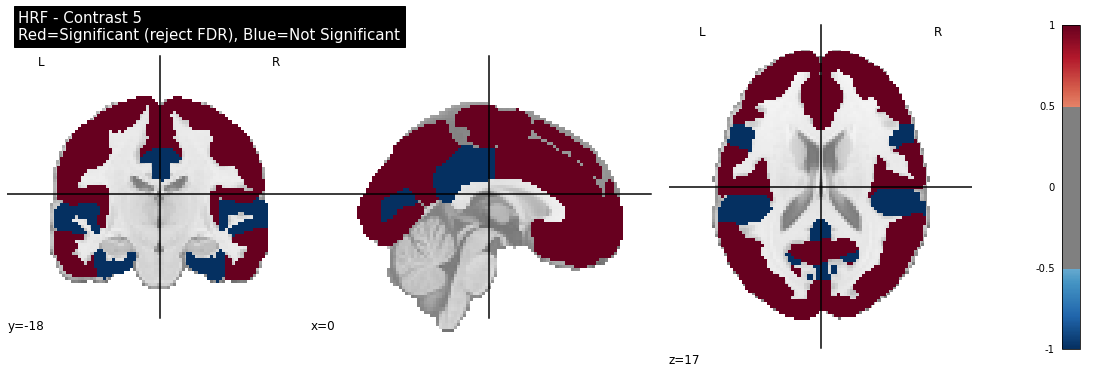

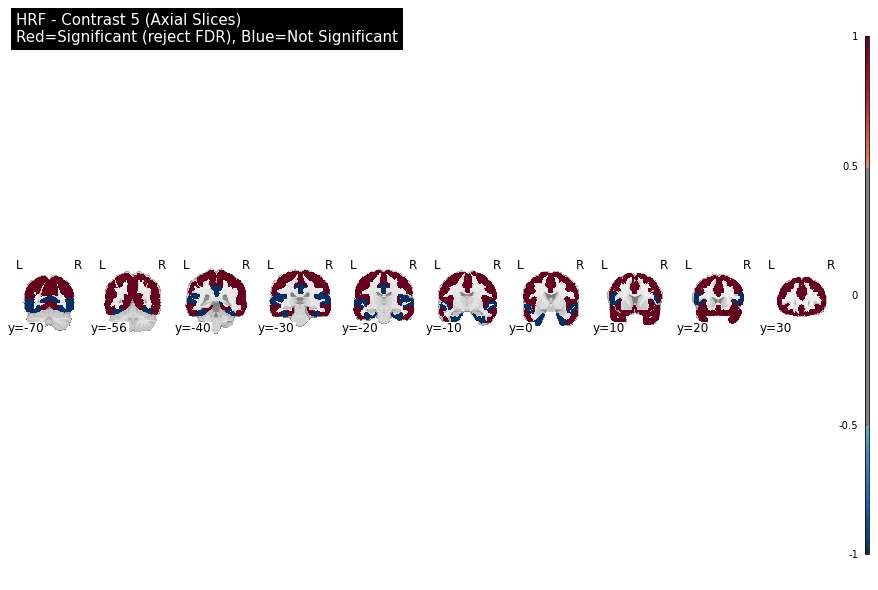

Brain maps created for hrf - Contrast 5
Total ROIs mapped: 48
Significant ROIs: 31
Non-significant ROIs: 17


In [66]:
factor = 'hrf'
contrast = 5  # Adjust this to match your contrast naming

# Filter df for this specific factor and contrast
subset = final_df[final_df['contrast'] == contrast].copy()

# Create a blank brain image (same shape as atlas)
significance_map = np.zeros_like(atlas_data)

# For each ROI in your results
for _, row in subset.iterrows():
    roi_num = int(row['roi'])  # ROI number from Harvard-Oxford atlas
    
    # Get rejection status
    reject = row[f'{factor}_reject_fdr']
    
    # Assign binary value: 1 for significant (red), -1 for not significant (blue)
    if reject:
        value = 1.0  # Significant - will show as red
    else:
        value = -1.0  # Not significant - will show as blue
    
    # Set all voxels in this ROI to this value
    significance_map[atlas_data == roi_num] = value

# Create NIfTI image from the significance map
significance_img = nib.Nifti1Image(significance_map, atlas_img.affine)

# Plot using regular brain (stat_map with orthogonal view)
fig = plt.figure(figsize=(15, 5))
display = plotting.plot_stat_map(
    significance_img,
    display_mode='ortho',  # Orthogonal view (sagittal, coronal, axial)
    colorbar=True,
    cmap='RdBu_r',  # Red for significant, Blue for not significant
    symmetric_cbar=True,
    vmax=1.0,
    title=f'{factor.upper()} - Contrast {contrast}\nRed=Significant (reject FDR), Blue=Not Significant',
    figure=fig,
    threshold=0.5,  # Show all non-zero voxels
    cut_coords=None  # Automatic cut coordinate selection
)

plt.savefig(f'brain_map_{factor}_contrast{contrast}.png', dpi=300, bbox_inches='tight')
plt.show()

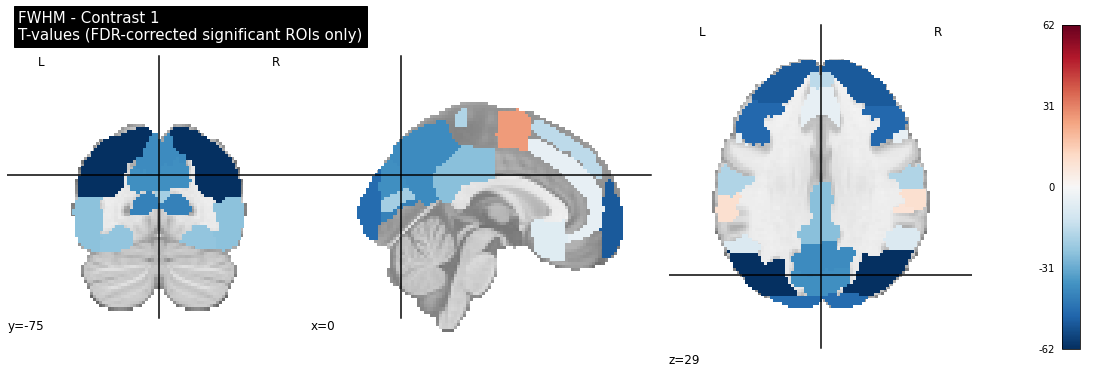

In [73]:
factor = 'fwhm'
contrast = 1  # Adjust this to match your contrast naming

# Filter df for this specific factor and contrast
subset = final_df[final_df['contrast'] == contrast].copy()

# Create two maps: one for t-values, one for the mask
tvalue_map = np.zeros_like(atlas_data)
mask_map = np.zeros_like(atlas_data, dtype=bool)

# For each ROI in your results
for _, row in subset.iterrows():
    roi_num = int(row['roi'])  # ROI number from Harvard-Oxford atlas
    
    # Get t-value and rejection status
    t_value = row[f'{factor}_t_value']
    reject = row[f'{factor}_reject_fdr']
    
    # Set t-value for all voxels in this ROI
    tvalue_map[atlas_data == roi_num] = t_value
    
    # Only mark as part of mask if reject_fdr is True
    if reject:
        mask_map[atlas_data == roi_num] = True

# Mask the t-value map - set non-significant ROIs to zero
masked_tvalue_map = np.where(mask_map, tvalue_map, 0)

# Create NIfTI image from the masked t-value map
tvalue_img = nib.Nifti1Image(masked_tvalue_map, atlas_img.affine)

# Plot using regular brain (orthogonal view)
fig = plt.figure(figsize=(15, 5))
display = plotting.plot_stat_map(
    tvalue_img,
    display_mode='ortho',  # Orthogonal view (sagittal, coronal, axial)
    colorbar=True,
    cmap='RdBu_r',  # Red for positive t-values, Blue for negative
    title=f'{factor.upper()} - Contrast {contrast}\nT-values (FDR-corrected significant ROIs only)',
    figure=fig,
    threshold=1e-6,  # Show only non-zero voxels (significant ROIs)
    cut_coords=None  # Automatic cut coordinate selection
)

plt.savefig(f'tvalue_map_{factor}_contrast{contrast}.png', dpi=300, bbox_inches='tight')
plt.show()


In [72]:
contrasts = [1, 2, 3, 4, 5]
predictors = ['motion_reg', 'fwhm', 'hrf']

# Loop through all combinations
for contrast in contrasts:
    for factor in predictors:
        # Filter df for this specific factor and contrast
        subset = final_df[final_df['contrast'] == contrast].copy()
        
        # Create a blank brain image (same shape as atlas)
        significance_map = np.zeros_like(atlas_data)
        
        # For each ROI in your results
        for _, row in subset.iterrows():
            roi_num = int(row['roi'])  # ROI number from Harvard-Oxford atlas
            
            # Get rejection status
            reject = row[f'{factor}_reject_fdr']
            
            # Assign binary value: 1 for significant (red), -1 for not significant (blue)
            if reject:
                value = 1.0  # Significant - will show as red
            else:
                value = -1.0  # Not significant - will show as blue
            
            # Set all voxels in this ROI to this value
            significance_map[atlas_data == roi_num] = value
        
        # Create NIfTI image from the significance map
        significance_img = nib.Nifti1Image(significance_map, atlas_img.affine)
        
        # Plot using regular brain (stat_map with orthogonal view)
        fig = plt.figure(figsize=(15, 5))
        display = plotting.plot_stat_map(
            significance_img,
            display_mode='ortho',  # Orthogonal view (sagittal, coronal, axial)
            colorbar=True,
            cmap='RdBu_r',  # Red for significant, Blue for not significant
            symmetric_cbar=True,
            vmax=1.0,
            title=f'{factor.upper()} - Contrast {contrast}\nRed=Significant (reject FDR), Blue=Not Significant',
            figure=fig,
            threshold=0.5,  # Show all non-zero voxels
            cut_coords=None  # Automatic cut coordinate selection
        )
        
        # Save with descriptive filename
        plt.savefig(f'brain_map_{factor}_contrast{contrast}.png', dpi=300, bbox_inches='tight')
        plt.close()  # Close figure to free memory
        
        print(f"Saved: brain_map_{factor}_contrast{contrast}.png")

print("\nAll 15 brain maps created successfully!")

Saved: brain_map_motion_reg_contrast1.png
Saved: brain_map_fwhm_contrast1.png
Saved: brain_map_hrf_contrast1.png
Saved: brain_map_motion_reg_contrast2.png
Saved: brain_map_fwhm_contrast2.png
Saved: brain_map_hrf_contrast2.png
Saved: brain_map_motion_reg_contrast3.png
Saved: brain_map_fwhm_contrast3.png
Saved: brain_map_hrf_contrast3.png
Saved: brain_map_motion_reg_contrast4.png
Saved: brain_map_fwhm_contrast4.png
Saved: brain_map_hrf_contrast4.png
Saved: brain_map_motion_reg_contrast5.png
Saved: brain_map_fwhm_contrast5.png
Saved: brain_map_hrf_contrast5.png

All 15 brain maps created successfully!


In [74]:
contrasts = [1, 2, 3, 4, 5]
predictors = ['motion_reg', 'fwhm', 'hrf']

# Loop through all combinations
for contrast in contrasts:
    for factor in predictors:
        # Filter df for this specific factor and contrast
        subset = final_df[final_df['contrast'] == contrast].copy()
        
        # Create two maps: one for t-values, one for the mask
        tvalue_map = np.zeros_like(atlas_data)
        mask_map = np.zeros_like(atlas_data, dtype=bool)
        
        # For each ROI in your results
        for _, row in subset.iterrows():
            roi_num = int(row['roi'])  # ROI number from Harvard-Oxford atlas
            
            # Get t-value and rejection status
            t_value = row[f'{factor}_t_value']
            reject = row[f'{factor}_reject_fdr']
            
            # Set t-value for all voxels in this ROI
            tvalue_map[atlas_data == roi_num] = t_value
            
            # Only mark as part of mask if reject_fdr is True
            if reject:
                mask_map[atlas_data == roi_num] = True
        
        # Mask the t-value map - set non-significant ROIs to zero
        masked_tvalue_map = np.where(mask_map, tvalue_map, 0)
        
        # Create NIfTI image from the masked t-value map
        tvalue_img = nib.Nifti1Image(masked_tvalue_map, atlas_img.affine)
        
        # Plot using regular brain (orthogonal view)
        fig = plt.figure(figsize=(15, 5))
        display = plotting.plot_stat_map(
            tvalue_img,
            display_mode='ortho',  # Orthogonal view (sagittal, coronal, axial)
            colorbar=True,
            cmap='RdBu_r',  # Red for positive t-values, Blue for negative
            title=f'{factor.upper()} - Contrast {contrast}\nT-values (FDR-corrected significant ROIs only)',
            figure=fig,
            threshold=1e-6,  # Show only non-zero voxels (significant ROIs)
            cut_coords=None  # Automatic cut coordinate selection
        )
        
        # Save with descriptive filename
        plt.savefig(f'tmap_{factor}_contrast{contrast}.png', dpi=300, bbox_inches='tight')
        plt.close()  # Close figure to free memory
        
        print(f"Saved: tmap_{factor}_contrast{contrast}.png")

print("\nAll 15 t-value brain maps created successfully!")

Saved: tmap_motion_reg_contrast1.png
Saved: tmap_fwhm_contrast1.png
Saved: tmap_hrf_contrast1.png
Saved: tmap_motion_reg_contrast2.png
Saved: tmap_fwhm_contrast2.png
Saved: tmap_hrf_contrast2.png
Saved: tmap_motion_reg_contrast3.png
Saved: tmap_fwhm_contrast3.png
Saved: tmap_hrf_contrast3.png
Saved: tmap_motion_reg_contrast4.png
Saved: tmap_fwhm_contrast4.png
Saved: tmap_hrf_contrast4.png
Saved: tmap_motion_reg_contrast5.png
Saved: tmap_fwhm_contrast5.png
Saved: tmap_hrf_contrast5.png

All 15 t-value brain maps created successfully!


/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


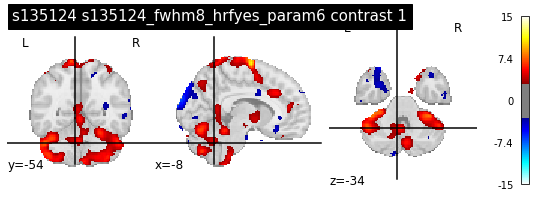

In [7]:
from nilearn import plotting

# subj_key = "s131823"
# pipeline_name = "s131823_fwhm8_hrfyes_param6"
subj_key = "s135124"
pipeline_name = "s135124_fwhm8_hrfyes_param6"
contrast = 1  # pick which contrast to plot

# Load the Nifti image
img = loaded[subj_key][pipeline_name][contrast]

# Plot it
plotting.plot_stat_map(
    img,
    threshold=3.0,
#     bg_img=None,
    display_mode='ortho',
    title=f"{subj_key} {pipeline_name} contrast {contrast}"
)
plotting.show()